In [14]:
## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

#modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [15]:
## import csv data
df = pd.read_csv('/Users/rajusubba/Documents/MLOpsProject/machinelearningproject/notebook/data/StudentsPerformance.csv')

In [16]:
# reading first 5 rows of the dataset
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [17]:
#creating independent features x by dropping math score
x = df[df.columns.drop('math score')]
x

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [18]:
#creating depenedent feature y
y = df['math score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [19]:
# create column transformer and preprocess categorical features
num_features = x.select_dtypes(exclude=['object']).columns
cat_features = x.select_dtypes(include=['object']).columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
    ("OneHotEncoder", oh_transformer, cat_features),
    ("StandardScaler", numeric_transformer, num_features),
    ]
    )

In [20]:
x = preprocessor.fit_transform(x)
x

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [23]:
# Seperate train and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape
x_train

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.05694554,  0.45733301],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.94779033,  0.98406266],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.35894946,  1.18158627],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
        -0.49126664, -0.99117351],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        -1.45063795, -0.99117351],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.4960025 ,  1.37910989]], shape=(800, 19))

In [30]:
## Create evaluation function to gice all model metrics after training
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square    

In [37]:
## models to train
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(),
    "Ridge Regression": Ridge(),
    "KNeighbors Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBoost Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
    
}
model_list = []
r2_list = []

for name, model in models.items():
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    model_list.append(name)
    r2_list.append(test_r2)   # ✅ keep best metric list

    print(name)
    print("Model performance for training set")
    print(f"- RMSE: {train_rmse:.4f}")
    print(f"- MAE: {train_mae:.4f}")
    print(f"- R2:  {train_r2:.4f}")

    print("--------------------------------")

    print("Model performance for test set")
    print(f"- RMSE: {test_rmse:.4f}")
    print(f"- MAE: {test_mae:.4f}")
    print(f"- R2:  {test_r2:.4f}")
    print("=" * 35, "\n")

Linear Regression
Model performance for training set
- RMSE: 5.3231
- MAE: 4.2667
- R2:  0.8743
--------------------------------
Model performance for test set
- RMSE: 5.3940
- MAE: 4.2148
- R2:  0.8804

Lasso Regression
Model performance for training set
- RMSE: 6.5938
- MAE: 5.2063
- R2:  0.8071
--------------------------------
Model performance for test set
- RMSE: 6.5197
- MAE: 5.1579
- R2:  0.8253

Ridge Regression
Model performance for training set
- RMSE: 5.3233
- MAE: 4.2650
- R2:  0.8743
--------------------------------
Model performance for test set
- RMSE: 5.3904
- MAE: 4.2111
- R2:  0.8806

KNeighbors Regressor
Model performance for training set
- RMSE: 5.7172
- MAE: 4.5270
- R2:  0.8550
--------------------------------
Model performance for test set
- RMSE: 7.2553
- MAE: 5.6280
- R2:  0.7837

Decision Tree Regressor
Model performance for training set
- RMSE: 0.2795
- MAE: 0.0187
- R2:  0.9997
--------------------------------
Model performance for test set
- RMSE: 8.0256
- 

In [38]:
print("len(model_list):", len(model_list))
print("len(r2_list):", len(r2_list))

print("model_list sample:", model_list[:5])
print("r2_list sample:", r2_list[:5])

len(model_list): 9
len(r2_list): 9
model_list sample: ['Linear Regression', 'Lasso Regression', 'Ridge Regression', 'KNeighbors Regressor', 'Decision Tree Regressor']
r2_list sample: [0.8804332983749564, 0.8253197323627852, 0.8805931485028738, 0.7836806685669011, 0.7353068812813761]


In [39]:
#Best r2 score
pd.DataFrame(list(zip(model_list, r2_list)), columns = ['Model Name', 'R2 Score']).sort_values(by=["R2 Score"], ascending=False)

,Model Name,R2 Score
2,Ridge Regression,0.880593
0,Linear Regression,0.880433
7,CatBoost Regressor,0.851632
5,Random Forest Regressor,0.850786
8,AdaBoost Regressor,0.846920
6,XGBoost Regressor,0.827797
1,Lasso Regression,0.825320
3,KNeighbors Regressor,0.783681
4,Decision Tree Regressor,0.735307


In [41]:
#Linear Regression has the best R2 Score of 0.8362

lin_model = LinearRegression(fit_intercept = True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred)
print("R2 score: %.2f" % score)


R2 score: 0.88


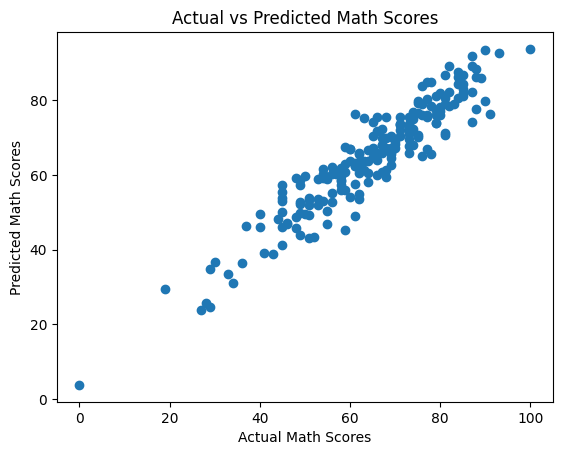

In [42]:
##plot y_pred vs y_test
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Math Scores")
plt.ylabel("Predicted Math Scores")
plt.title("Actual vs Predicted Math Scores")
plt.show()

In [44]:
# Difference between actual and predicted values
pred_diff = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Difference': y_test - y_pred})
pred_diff.head(10)

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
678,81,79.014024,1.985976
626,69,64.654609,4.345391
513,54,53.007919,0.992081
859,87,74.184710,12.815290
136,51,49.213538,1.786462
